In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pickle

In [12]:

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
snapnum=40

In [5]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200", "Group_R_TopHat200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [6]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [43]:
mvir_lin = halos["Group_M_TopHat200"]*1e10
mfof_lin = halos["GroupMass"]*1e10

In [7]:
rvir = halos["Group_R_TopHat200"]

In [20]:
sfrs = halos["GroupSFR"]

Text(0.5, 1.0, 'logM13-13.5')

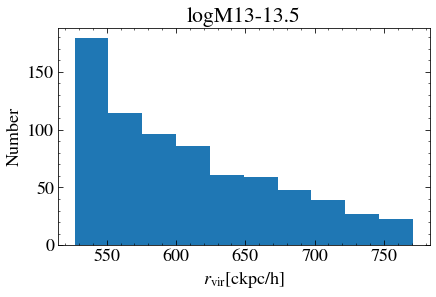

In [42]:
logMmin = 13
logMmax = 13.5
mask = (mvir>logMmin) & (mvir < logMmax)
plt.hist(rvir[mask])
plt.xlabel("$r_{\mathrm{vir}}$[ckpc/h]")
plt.ylabel("Number")
plt.title(f"logM{logMmin}-{logMmax}")

Text(0.5, 1.0, 'logM13-13.5')

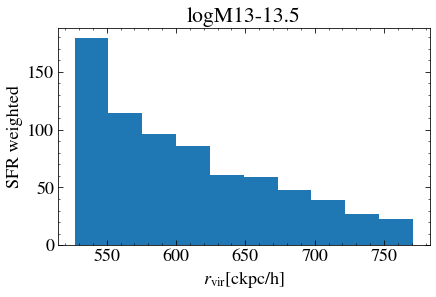

In [48]:
mass_ratio = mfof_lin[mask]/mvir_lin[mask]
r_ratio = mass_ratio**(1/3)
plt.hist(rvir[mask])


plt.hist(rvir[mask], weights=sfrs[mask], density=True,histtype="step")
#plt.hist(rvir[mask]*r_ratio, weights=sfrs[mask], density=True)
plt.xlabel("$r_{\mathrm{vir}}$[ckpc/h]")
plt.ylabel("SFR weighted")
plt.title(f"logM{logMmin}-{logMmax}")

Text(0.5, 1.0, 'logM11.4-11.5')

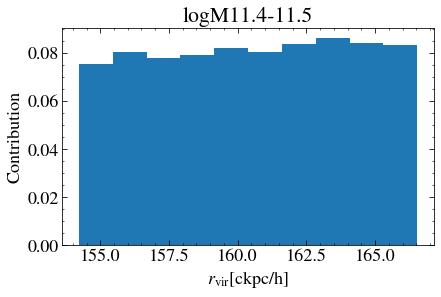

In [38]:

plt.hist(rvir[mask], weights=sfrs[mask], density=True)
plt.xlabel("$r_{\mathrm{vir}}$[ckpc/h]")
plt.ylabel("Contribution")
plt.title(f"logM{logMmin}-{logMmax}")

In [39]:
np.sum(rvir[mask]*sfrs[mask])/np.sum(sfrs[mask])

160.49075

In [40]:
np.sum(mvir[mask]*sfrs[mask])/np.sum(sfrs[mask])

11.451552

(array([3308., 2820., 2308., 1994., 1604., 1345., 1192., 1017.,  809.,
         685.]),
 array([244.43408, 255.86743, 267.30078, 278.73413, 290.16748, 301.60083,
        313.03418, 324.46753, 335.90088, 347.33423, 358.76758],
       dtype=float32),
 <BarContainer object of 10 artists>)

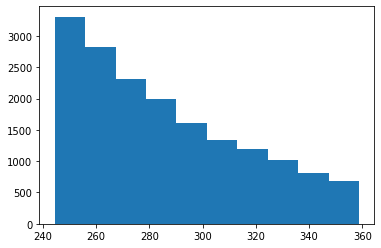

In [9]:
plt.hist(rvir[(mvir>12) & (mvir<12.5)])